<a href="https://colab.research.google.com/github/mcnica89/DATA6100/blob/main/MNIST_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import jax.numpy as jnp
import jax
import time

#Load MNIST Dataset

In [2]:
import numpy as np
from torch.utils import data
from torchvision.datasets import MNIST

def numpy_collate(batch):
  if isinstance(batch[0], np.ndarray):
    return np.stack(batch)
  elif isinstance(batch[0], (tuple,list)):
    transposed = zip(*batch)
    return [numpy_collate(samples) for samples in transposed]
  else:
    return np.array(batch)

class NumpyLoader(data.DataLoader):
  def __init__(self, dataset, batch_size=1,
                shuffle=False, sampler=None,
                batch_sampler=None, num_workers=0,
                pin_memory=False, drop_last=False,
                timeout=0, worker_init_fn=None):
    super(self.__class__, self).__init__(dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        sampler=sampler,
        batch_sampler=batch_sampler,
        num_workers=num_workers,
        collate_fn=numpy_collate,
        pin_memory=pin_memory,
        drop_last=drop_last,
        timeout=timeout,
        worker_init_fn=worker_init_fn)

class FlattenAndCast(object):
  def __call__(self, pic):
    return np.ravel(np.array(pic, dtype=jnp.float32))

In [3]:
# Define our dataset, using torch datasets
mnist_dataset = MNIST('/tmp/mnist/', download=True, transform=FlattenAndCast())

batch_size = 128
training_generator = NumpyLoader(mnist_dataset, batch_size=batch_size, num_workers=0)

  0%|          | 0/9912422 [00:00<?, ?it/s]

Extracting /tmp/mnist/MNIST/raw/train-images-idx3-ubyte.gz to /tmp/mnist/MNIST/raw



  0%|          | 0/28881 [00:00<?, ?it/s]

Extracting /tmp/mnist/MNIST/raw/train-labels-idx1-ubyte.gz to /tmp/mnist/MNIST/raw



  0%|          | 0/1648877 [00:00<?, ?it/s]

Extracting /tmp/mnist/MNIST/raw/t10k-images-idx3-ubyte.gz to /tmp/mnist/MNIST/raw



  0%|          | 0/4542 [00:00<?, ?it/s]

Extracting /tmp/mnist/MNIST/raw/t10k-labels-idx1-ubyte.gz to /tmp/mnist/MNIST/raw



## Train and test sets

In [4]:
# Get the full train dataset (for checking accuracy while training)
train_images = np.array(mnist_dataset.train_data).reshape(len(mnist_dataset.train_data), -1)
train_labels = np.array(mnist_dataset.train_labels)

N_train = 10000
train_images = train_images[0:N_train,:] #get a subset of the data
train_labels = train_labels[0:N_train] 


# Get full test dataset
mnist_dataset_test = MNIST('/tmp/mnist/', download=True, train=False)
test_images = jnp.array(mnist_dataset_test.test_data.numpy().reshape(len(mnist_dataset_test.test_data), -1), dtype=jnp.float32)
test_labels = np.array(mnist_dataset_test.test_labels)


N_test = 10000
test_images = test_images[0:N_test,:] #get a subset of the data
test_labels = test_labels[0:N_test] 

/usr/local/lib/python3.7/dist-packages/torchvision/datasets/mnist.py:75: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")
/usr/local/lib/python3.7/dist-packages/torchvision/datasets/mnist.py:65: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.7/dist-packages/torchvision/datasets/mnist.py:80: UserWarning: test_data has been renamed data
  warnings.warn("test_data has been renamed data")
/usr/local/lib/python3.7/dist-packages/torchvision/datasets/mnist.py:70: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


## Plotting examples of MNIST dataset

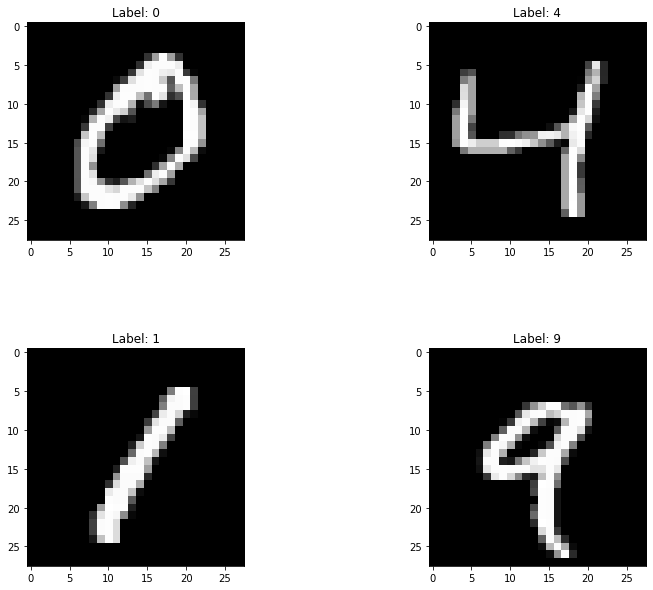

In [5]:
import matplotlib.pyplot as plt

def plot_MNIST_train_examples(my_labels,n_grid = 2):
  figure = plt.figure(figsize=(12, 10))

  #plotting images from the training set
  for i in range(1, n_grid**2 + 1):
    plt.subplot(n_grid, n_grid, i)
    plt.subplots_adjust(hspace =.5, wspace=.5)
    plt.title(f"Label: {my_labels[i]}")  
  
    img = train_images[i].reshape((28,28))
    plt.imshow(img, cmap='gray')

plot_MNIST_train_examples(train_labels)

# Linear Regression (LinR)

We think of linear regression as a [784 by 1] graph.

## Generate random starting paramaters

In [6]:
# A helper function to randomly initialize weights and biases
# for a dense neural network layer
def random_layer_params(m, n, key, scale=1e-2):
  w_key, b_key = jax.random.split(key)
  return scale * jax.random.normal(w_key, (n, m)), scale * jax.random.normal(b_key, (n,))

# Initialize all layers for a fully-connected neural network with sizes "sizes"
def init_network_params(sizes, key):
  keys = jax.random.split(key, len(sizes))
  return [random_layer_params(m, n, k) for m, n, k in zip(sizes[:-1], sizes[1:], keys)]

key = jax.random.PRNGKey(int(time.time()))

In [7]:
layer_sizes = [784, 1]
params = init_network_params(layer_sizes, key)

## Create our function and our loss function

In [8]:
layer_sizes = [784, 1]
params = init_network_params(layer_sizes, key)

def LinR(params, image):
  x = image 
  # first layer is feedforward 
  w, b = params[0]
  return (jnp.dot(w, x) + b)[0]

print("Lin Reg on 1st training example:")
print(LinR(params,train_images[0]))

Lin Reg on 1st training example:
20.26434


In [9]:
batched_LinR = jax.vmap(LinR, in_axes=(None, 0))

print("Lin Reg on all training example:")
print(batched_LinR(params,train_images))

Lin Reg on all training example:
[20.26434    9.618589   2.0212018 ... 11.079499  -4.619829   7.5941925]


In [10]:
def MSE_loss_for_LinR(params,images,target):
  preds = batched_LinR(params, images)
  return jnp.mean( (preds - target)**2 )

print("MSE loss of LinR on training set:")
print(MSE_loss_for_LinR(params,train_images,train_labels))

MSE loss of LinR on training set:
553.8935


# Training loop using gradient descent

In [11]:
import time 

from functools import partial

@partial(jax.jit, static_argnames=['loss_func','step_size'])
def update_params(params, x, y, loss_func, step_size):
  grads = jax.grad(loss_func)(params, x, y)

  return [(w - step_size * dw, b - step_size * db) 
          for (w, b), (dw, db) in zip(params, grads)]

#trains ``params'' according to the given loss_func
def training_loop(loss_func, acc_func=None, num_epochs = 2, step_size = 0.01):
  global params    
  saved_results = []
  for epoch in range(1,num_epochs+1):

      #Update the weights by gradient descent!
      start_time = time.time()
      for x, y in training_generator: 
          #turn the labels into one hot vectors
          #grads = jax.grad(loss_func)(params, x, y)

          params = update_params(params, x, y, loss_func, step_size)
          
          #[(w - step_size * dw, b - step_size * db) 
          # for (w, b), (dw, db) in zip(params, grads)]

      #### A bunch of bookeeping here.... ####
      #Print and record stats of this epoch
      if acc_func != None:
        train_acc = acc_func(params, train_images, train_labels)
        test_acc = acc_func(params, test_images, test_labels)
      
      train_CE_loss = loss_func(params, train_images, train_labels)
      test_CE_loss = loss_func(params, test_images, test_labels)
    
      results_dict = {'epoch': epoch, 
              'train_loss': np.copy(train_CE_loss).item(), 
              'test_loss': np.copy(test_CE_loss).item(),
              }

      if acc_func != None:
        results_dict['train_acc'] = np.copy(train_acc).item() 
        results_dict['test_acc'] = np.copy(test_acc).item()
              
      saved_results += [results_dict]

      epoch_time = time.time() - start_time
      print(f"---Epoch {epoch} in {epoch_time:0.2f} sec---")
      if acc_func != None:
        print(f"  Train  acc: {train_acc:0.4f}")
        print(f"  Test   acc: {test_acc:0.4f}")
      print(f"  Train loss: {train_CE_loss:0.4f}")
      print(f"  Test  loss: {test_CE_loss:0.4f}")

  
  return saved_results

In [12]:
layer_sizes = [784, 1]
params = init_network_params(layer_sizes, key)
training_loop(MSE_loss_for_LinR,num_epochs=2,step_size = 0.00000001)

---Epoch 1 in 5.83 sec---
  Train loss: 141.3416
  Test  loss: 138.0807
---Epoch 2 in 4.12 sec---
  Train loss: 91.1004
  Test  loss: 88.1882


[{'epoch': 1, 'train_loss': 141.341552734375, 'test_loss': 138.08071899414062},
 {'epoch': 2, 'train_loss': 91.10044860839844, 'test_loss': 88.18817901611328}]

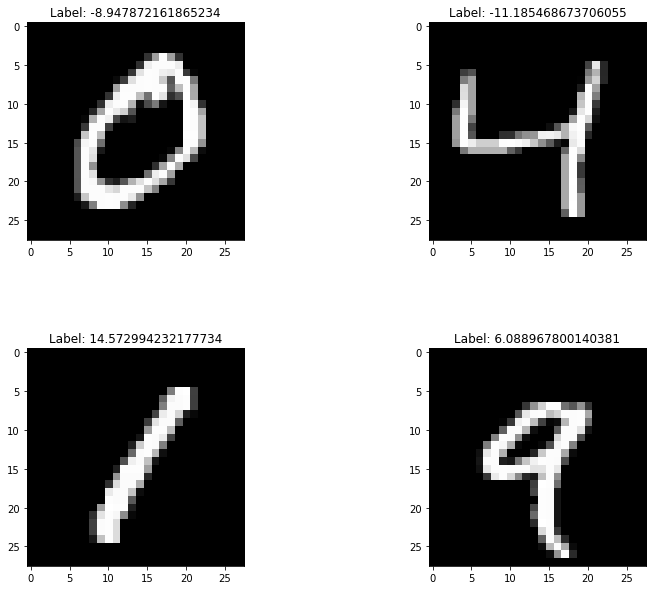

In [13]:
LinR_labels = batched_LinR(params, train_images)
plot_MNIST_train_examples(LinR_labels)

# Non-linear but still regression (NonLinR)

In [14]:
layer_sizes = [784, 1]
params = init_network_params(layer_sizes, key)

def sigmoid(x):
  return jnp.exp(x)/(1+jnp.exp(x))

def NonLinR(params, image):
  x = image 
  # first layer is feedforward 
  w, b = params[0]
  return 9*sigmoid( (jnp.dot(w, x) + b)[0] )

print("NonLinR on a single example:")
print(NonLinR(params,train_images[0]))

batched_NonLinR = jax.vmap(NonLinR, in_axes=(None, 0))
print("NonLinR on a all examples:")
print(batched_NonLinR(params,train_images))

def MSE_loss_for_NonLinR(params,images,target):
  preds = batched_NonLinR(params, images)
  return jnp.mean( (preds - target)**2 )

print("MSE of train set for NonLin R")
print(MSE_loss_for_NonLinR(params,train_images,train_labels))

NonLinR on a single example:
8.999999
NonLinR on a all examples:
[8.999999   8.999402   7.947047   ... 8.999862   0.08782485 8.995472  ]
MSE of train set for NonLin R
nan


In [15]:
layer_sizes = [784, 1]
params = init_network_params(layer_sizes, key)
training_loop(MSE_loss_for_NonLinR,step_size = 0.000001)

---Epoch 1 in 3.08 sec---
  Train loss: 13.6413
  Test  loss: 13.4762
---Epoch 2 in 2.42 sec---
  Train loss: 10.8009
  Test  loss: 10.6274


[{'epoch': 1,
  'train_loss': 13.64128589630127,
  'test_loss': 13.476235389709473},
 {'epoch': 2,
  'train_loss': 10.800869941711426,
  'test_loss': 10.62736988067627}]

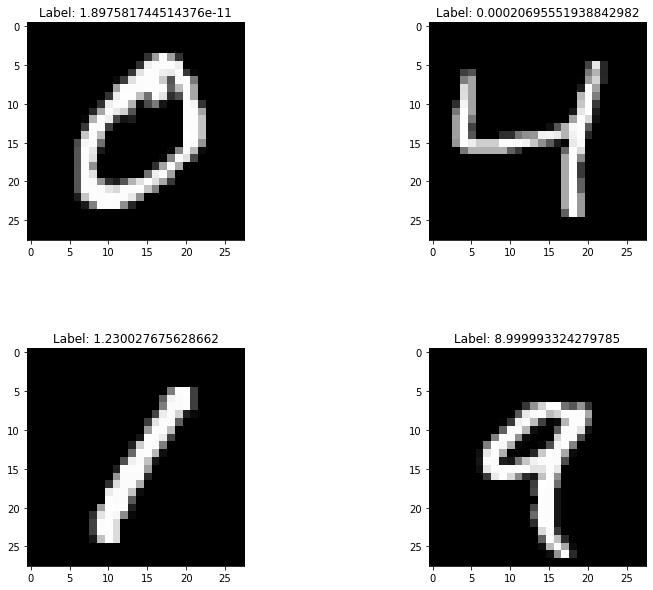

In [16]:
NonLinR_labels = batched_NonLinR(params, train_images)
plot_MNIST_train_examples(NonLinR_labels)

# Logisitic Regression (LogiR)

In [17]:
#Initialize Parameters

layer_sizes = [784, 10]
params = init_network_params(layer_sizes, key)

def sigmoid(x):
  return jnp.exp(x)/(1+jnp.exp(x))

def LogiR_logP(params, image):
  x = image 
  # first layer is feedforward 
  w, b = params[0]
  logits = jnp.dot(w, x) + b
  logits = logits - jnp.max(logits)
  logP = logits - jnp.log(jnp.sum(jnp.exp(logits)))
  return logP

print("LogiR on one example:")
print(LogiR_logP(params, train_images[0]))

batched_LogiR_logP = jax.vmap(LogiR_logP, in_axes=(None, 0))

print("LogiR on all examples:")
print(batched_LogiR_logP(params, train_images))



def CE_loss_for_LogiR(params,images,target):
  preds = batched_LogiR_logP(params, images)
  target_one_hot = jax.nn.one_hot(target, 10)
  return -jnp.mean(preds * target_one_hot) 


print("CE loss of LogiR on all example:")
print(CE_loss_for_LogiR(params,train_images,train_labels))

LogiR on one example:
[ -49.073143  -67.2969    -68.993355    0.       -102.54094   -53.0624
  -62.289715  -49.807182  -82.78138   -54.96551 ]
LogiR on all examples:
[[-49.073147 -67.2969   -68.993355 ... -49.807182 -82.78139  -54.965515]
 [-30.733757 -68.816765 -85.152115 ...  -9.947912 -29.682236 -56.294514]
 [-47.55464   -9.023978 -40.86164  ... -51.01772  -11.850604  -9.733687]
 ...
 [-14.15146  -71.38246  -64.652756 ... -25.459805 -63.42626  -21.09399 ]
 [-15.753366 -75.1644   -17.273972 ... -35.45009  -45.34944  -25.477142]
 [-50.056892 -57.338142 -37.791725 ... -43.107845 -77.60922  -35.211975]]
CE loss of LogiR on all example:
3.9391708


In [27]:
layer_sizes = [784, 10]
params = init_network_params(layer_sizes, key)

def top1_acc_LogiR(params, images, target_class):
  predicted_class = jnp.argmax(batched_LogiR_logP(params, images), axis=1)
  return jnp.mean(predicted_class == target_class)

training_loop(CE_loss_for_LogiR,top1_acc_LogiR,num_epochs=10,step_size = 0.001)
print("Done!")

---Epoch 1 in 3.02 sec---
  Train  acc: 0.8663
  Test   acc: 0.8612
  Train loss: 0.1666
  Test  loss: 0.1721
---Epoch 2 in 2.43 sec---
  Train  acc: 0.8629
  Test   acc: 0.8515
  Train loss: 0.1671
  Test  loss: 0.1839
---Epoch 3 in 2.44 sec---
  Train  acc: 0.8620
  Test   acc: 0.8531
  Train loss: 0.1663
  Test  loss: 0.1833
---Epoch 4 in 2.41 sec---
  Train  acc: 0.8745
  Test   acc: 0.8661
  Train loss: 0.1450
  Test  loss: 0.1644
---Epoch 5 in 2.41 sec---
  Train  acc: 0.8706
  Test   acc: 0.8636
  Train loss: 0.1470
  Test  loss: 0.1637
---Epoch 6 in 2.41 sec---
  Train  acc: 0.8662
  Test   acc: 0.8580
  Train loss: 0.1512
  Test  loss: 0.1673
---Epoch 7 in 2.39 sec---
  Train  acc: 0.8767
  Test   acc: 0.8659
  Train loss: 0.1384
  Test  loss: 0.1573
---Epoch 8 in 2.39 sec---
  Train  acc: 0.8670
  Test   acc: 0.8582
  Train loss: 0.1452
  Test  loss: 0.1667
---Epoch 9 in 2.39 sec---
  Train  acc: 0.8745
  Test   acc: 0.8654
  Train loss: 0.1429
  Test  loss: 0.1637
---Epoch 1

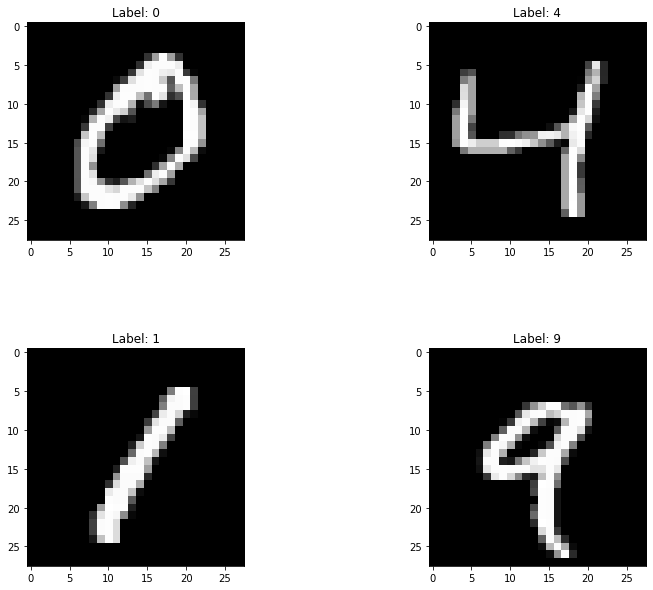

In [28]:
LogiR_labels = batched_LogiR_logP(params, train_images)
plot_MNIST_train_examples(jnp.argmax(LogiR_labels,axis=1))

## Multi-layer perceptron with cross entropy loss (MLP)

In [29]:
layer_sizes = [784, 784, 10]
params = init_network_params(layer_sizes, key)

# rectified linear unit activation function
def relu(x):
  return jnp.maximum(0, x) # compute the element-wise function

def MLP_logP(params, image):
    # per-example predictions
    x = image 
    # first layer is feedforward 
    w, b = params[0]
    x = (jnp.dot(w, x) + b) 
    x_relu = relu(x)
    
    for w, b in params[1:-1]:
        # skip pre activations
        x = (jnp.dot(w, x_relu) + b) 
        x_relu = relu(x)

    final_w, final_b = params[-1] 
    logits = (jnp.dot(final_w,  x) + final_b) 
    logits = logits - jnp.max(logits)
    return logits - jnp.log(jnp.sum(jnp.exp(logits)))

print("MLP logP on a single examples")
print(MLP_logP(params, train_images[0]))

MLP logP on a single examples
[-16.75351     -0.07369439 -17.509287    -8.751791    -2.6488898
  -9.503493   -13.208923    -9.434684   -27.754042   -16.248173  ]


In [30]:
# Let's upgrade it to handle batches using `vmap`

# Make a batched version of the `predict` function
batched_MLP_logP = jax.vmap(MLP_logP, in_axes=(None, 0))

# `batched_predict` has the same call signature as `predict`
print("MLP logP on all examples")
batched_preds = batched_MLP_logP(params, train_images)
print(batched_preds)

MLP logP on all examples
[[-1.6753511e+01 -7.3694274e-02 -1.7509287e+01 ... -9.4346819e+00
  -2.7754042e+01 -1.6248175e+01]
 [-4.9316254e+00 -1.4687273e-02 -1.8963642e+01 ... -6.4036074e+00
  -1.5197396e+01 -5.4619994e+00]
 [-1.4856676e+01 -6.8071661e+00 -1.0071333e+01 ... -7.8098950e+00
  -1.1594393e-01 -6.2874141e+00]
 ...
 [-2.2979712e+01 -6.0477592e-03 -2.2367579e+01 ... -1.6269163e+01
  -1.0618711e+01 -7.8097935e+00]
 [-1.4348514e+01 -1.4913831e+00 -1.3952032e+01 ... -2.1159840e+01
  -1.3711260e+01 -1.5830657e+01]
 [-1.5373232e+01 -1.5791401e+00 -9.5444937e+00 ... -8.5197296e+00
  -9.3745365e+00 -1.0964307e+01]]


# Loss function

In [31]:
def CE_loss_for_MLP(params, images, target):
  preds = batched_MLP_logP(params, images)
  target_one_hot = jax.nn.one_hot(target, 10)
  return -jnp.mean(preds * target_one_hot) 

print("CE loss for the the MLP")
print(CE_loss_for_MLP(params, train_images, train_labels))


CE loss for the the MLP
0.90391433


In [33]:
layer_sizes = [784, 784, 784, 10]
params = init_network_params(layer_sizes, key)


def top1_acc_MLP(params, images, target_class):
  predicted_class = jnp.argmax(batched_MLP_logP(params, images), axis=1)
  return jnp.mean(predicted_class == target_class)

training_loop(CE_loss_for_MLP, top1_acc_MLP, num_epochs=10)

---Epoch 1 in 2.95 sec---
  Train  acc: 0.9246
  Test   acc: 0.9278
  Train loss: 0.0249
  Test  loss: 0.0247
---Epoch 2 in 2.68 sec---
  Train  acc: 0.9449
  Test   acc: 0.9448
  Train loss: 0.0184
  Test  loss: 0.0190
---Epoch 3 in 2.68 sec---
  Train  acc: 0.9567
  Test   acc: 0.9527
  Train loss: 0.0147
  Test  loss: 0.0157
---Epoch 4 in 2.70 sec---
  Train  acc: 0.9652
  Test   acc: 0.9593
  Train loss: 0.0123
  Test  loss: 0.0136
---Epoch 5 in 2.59 sec---
  Train  acc: 0.9698
  Test   acc: 0.9631
  Train loss: 0.0105
  Test  loss: 0.0122
---Epoch 6 in 3.08 sec---
  Train  acc: 0.9730
  Test   acc: 0.9659
  Train loss: 0.0092
  Test  loss: 0.0112
---Epoch 7 in 3.05 sec---
  Train  acc: 0.9765
  Test   acc: 0.9669
  Train loss: 0.0082
  Test  loss: 0.0105
---Epoch 8 in 2.64 sec---
  Train  acc: 0.9788
  Test   acc: 0.9687
  Train loss: 0.0073
  Test  loss: 0.0099
---Epoch 9 in 2.66 sec---
  Train  acc: 0.9813
  Test   acc: 0.9700
  Train loss: 0.0066
  Test  loss: 0.0095
---Epoch 1

[{'epoch': 1,
  'train_loss': 0.024888671934604645,
  'test_loss': 0.024672340601682663,
  'train_acc': 0.9246000051498413,
  'test_acc': 0.9277999997138977},
 {'epoch': 2,
  'train_loss': 0.01840963028371334,
  'test_loss': 0.018969235941767693,
  'train_acc': 0.9448999762535095,
  'test_acc': 0.9447999596595764},
 {'epoch': 3,
  'train_loss': 0.014704938977956772,
  'test_loss': 0.01569264382123947,
  'train_acc': 0.9566999673843384,
  'test_acc': 0.9526999592781067},
 {'epoch': 4,
  'train_loss': 0.012285533361136913,
  'test_loss': 0.013612411916255951,
  'train_acc': 0.9651999473571777,
  'test_acc': 0.9592999815940857},
 {'epoch': 5,
  'train_loss': 0.010545430704951286,
  'test_loss': 0.01220209151506424,
  'train_acc': 0.9697999954223633,
  'test_acc': 0.9630999565124512},
 {'epoch': 6,
  'train_loss': 0.009226648136973381,
  'test_loss': 0.011213410645723343,
  'train_acc': 0.9729999899864197,
  'test_acc': 0.9659000039100647},
 {'epoch': 7,
  'train_loss': 0.00817440077662468

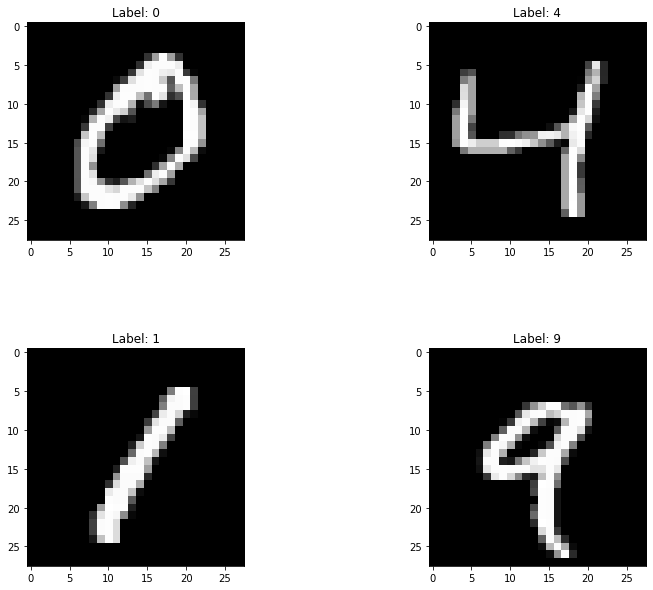

In [34]:
MLP_preds = batched_MLP_logP(params, train_images)
MLP_labels = jnp.argmax(MLP_preds,axis=1)
plot_MNIST_train_examples( MLP_labels)